### Libraries and Imports


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from datetime import date
%matplotlib inline
from trajectory_video import make_trajectory_video
from trajectory_video2 import make_trajectory_video1
from training_progress_video import make_training_progress_video
import re
import glob
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

### PDE and FD reference Parameters and RL action space


In [2]:
# PDE 
alpha = 0.05

#   FD reference grid   
nx    = 100
T     = 1
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

#  True solution; Analytical diffusion solution

def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

 

### FD For diffusion

In [3]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

### __ init __

In [4]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
        self._idx_set       = set()               
        self.rejected_history = []  # (x, t) per rejected move
    def add(self, x, t, u):
        self._idx_set.add((round(x / dx), round(t / dt)))  
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()
    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0
    def contains(self, x, t):                    
        return (round(x / dx), round(t / dt)) in self._idx_set
    def find_neighbours(self, x_star, t_star, n):
        if len(self._pts) < n:
            return None
        pts_arr  = np.asarray(self._pts)
        norm_arr = np.asarray(self._norm)

        # causal filter: neighbours at or before the query time
        mask = pts_arr[:, 1] <= t_star

        # a point can never be its own neighbour: exclude the exact query cell
        same_cell = (np.round(pts_arr[:, 0] / dx) == round(x_star / dx)) & \
                    (np.round(pts_arr[:, 1] / dt) == round(t_star / dt))
        mask &= ~same_cell

        if mask.sum() < n:
            return None
        norm_c = norm_arr[mask]
        pts_c  = pts_arr[mask]
        target = np.array([x_star / dx, t_star / dt])
        d2     = np.sum((norm_c - target) ** 2, axis=1)
        idx = np.argpartition(d2, n - 1)[:n]
        idx = idx[np.argsort(d2[idx])]
        return [tuple(row) for row in pts_c[idx]]

    def __len__(self):
            return len(self._pts)

### GFDM Solver


In [5]:
def solve_weights(dx_i, dt_i):
    h = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    #cond = np.linalg.cond(A)
    #if cond > 1e4:
    #    return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    #if np.max(np.abs(w)) > 3.0 / len(dx_i):
    #    return None, 'weights'
    #if np.min(w) < -1.0:
    #    return None, 'weights'

    return w, 'ok'

### PDEEnvironment

In [6]:
class PDEEnvironment(gym.Env):
    ACTIONS = {0: (-1, 1), 1: (-1, 2), 2: (-1, 3),
               3: ( 0, 1), 4: ( 0, 2), 5: ( 0, 3),
               6: ( 1, 1), 7: ( 1, 2), 8: ( 1, 3)}

    def __init__(self, t_star_schedule=None, t_star_steps=2, N_particles=27,
                 lam=0.001, beta=100.0, K_max=500, c_shape=0.0,
                 x_star_schedule=None):          # NEW: list of x* indices to sample
        super().__init__()

        self.alpha = alpha
        self.c_shape = c_shape

        self.nx = nx; self.nt = nt
        self.x_fd = x_fd; self.t_fd = t_fd
        self.dx = dx; self.dt = dt; self.T = T

        self.t_star_schedule = dict(t_star_schedule) if t_star_schedule else None

        # ── x* schedule: list of grid indices to sample from. None → fixed center.
        # Store as x_fd values so x* always lands on the grid.
        if x_star_schedule is not None:
            self.x_star_choices = np.array(
                [self.x_fd[int(ix)] for ix in x_star_schedule], dtype=float)
        else:
            self.x_star_choices = None

        # ── Target point (z*) ──
        self.x_star = self.x_fd[self.nx // 2]     # provisional; reset() may override
        self.t_star_steps = t_star_steps
        self.t_star = t_star_steps * dt

        self.K_max = K_max
        self.lam = lam
        self.beta = beta
        self.n_neighbours = 5
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions: FROZEN to domain center, INDEPENDENT of x* ──
        self.N = N_particles
        mid = self.nx // 2
        margin = 2
        half_n = self.N // 2
        step = (mid - margin) / half_n if half_n > 0 else 0
        offsets = [0]; k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1
        init_idx = np.clip(
            np.round(np.array(offsets[:self.N]) + mid).astype(int),
            margin, self.nx - 1 - margin)
        self.walker_init_x = self.x_fd[init_idx]   # does NOT depend on x_star

        _, self.fd_interp = build_fd_reference()

        self.visited = None
        self.walker_x = None
        self.walker_t = None
        self.walker_u = None
        self.step_count = 0
        self.stencil_log = {}

        # obs: 2N relative coords + t*_norm + x*_norm  → 2N+2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(2 * self.N + 2,), dtype=np.float32)
        self.action_space = spaces.Discrete(self.N * len(self.ACTIONS))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if self.t_star_schedule is not None:
            choices = list(self.t_star_schedule.keys())
            self.t_star_steps = int(self.np_random.choice(choices))
            self.t_star = self.t_star_steps * self.dt
            self.K_max = self.t_star_schedule[self.t_star_steps]

        # ── Resample x* per episode if a schedule is set ──
        if self.x_star_choices is not None:
            self.x_star = float(self.np_random.choice(self.x_star_choices))

        self.visited = VisitedSet()
        self.stencil_log = {}

        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_x])
        self.step_count = 0
        self.rejected_history = []
        self.gfdm_rejected_set = set()
        self._phi_prev = self._potential()

        return self._build_obs(), {}

    def _build_obs(self):
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        t_star_norm = self.t_star / self.dt          # horizon length in step units
        x_star_norm = self.x_star / self.dx          # NEW: absolute x* in dx units
        return np.array([
            *dx_rel,
            *dt_rel,
            t_star_norm,
            x_star_norm,
        ], dtype=np.float32)

    def _potential(self):
        if self.c_shape == 0.0:
            return 0.0
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        d = np.sqrt(dx_rel**2 + dt_rel**2)
        return -self.c_shape * float(np.mean(d))

    def _gfdm_solve(self, x_star, t_star):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False, None, 'no_nb'
        nb = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star
        w, reason = solve_weights(dx_i, dt_i)
        if w is None:
            return None, False, None, reason
        u_hat = float(w @ nb[:, 2])
        if abs(u_hat) > 1.1:
            return None, False, None, 'bounds_u'
        return u_hat, True, nb[:, :2], 'ok'

    def step(self, action):
        self.step_count += 1
        done = False
        reward = 0.0

        i = int(action) // len(self.ACTIONS)
        j = int(action) % len(self.ACTIONS)
        dx_idx, dt_idx = self.ACTIONS[j]
        dx_move = dx_idx * self.dx
        dt_move = dt_idx * self.dt

        info = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

        x_new = self.walker_x[i] + dx_move
        t_new = self.walker_t[i] + dt_move

        if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
            info['rejected'] = 'bounds'
        elif self.visited.contains(x_new, t_new):
            info['rejected'] = 'collision'
        else:
            u_hat, success, nb_coords, reason = self._gfdm_solve(x_new, t_new)
            if not success:
                info['rejected'] = reason
                self.gfdm_rejected_set.add(int(action))
            else:
                self.gfdm_rejected_set.clear()
                self.visited.add(x_new, t_new, u_hat)
                self.walker_x[i] = x_new
                self.walker_t[i] = t_new
                self.walker_u[i] = u_hat
                self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords
                info['accepted'] = True
                if (abs(x_new - self.x_star) < self.eps_x and
                        abs(t_new - self.t_star) < self.eps_t):
                    done = True
                    info['reached'] = True

        if not info['accepted']:
            self.rejected_history.append((x_new, t_new, info['rejected']))

        if done:
            u_pred, _, _, _ = self._gfdm_solve(self.x_star, self.t_star)
            u_ref = u_true(self.x_star, self.t_star)
            worst_case_timeout = -1 - self.lam * self.K_max
            if u_pred is None:
                reward = worst_case_timeout
                info['error'] = None
            else:
                reward = -(self.beta * abs(u_pred - u_ref) + self.lam * self.step_count)
                info['u_pred'] = u_pred
                info['u_ref'] = u_ref
                info['error'] = abs(u_pred - u_ref)
                info['k_term'] = self.step_count
        elif self.step_count >= self.K_max:
            done = True
            reward = -1 - self.lam * self.step_count
            info['timeout'] = True

        phi_new = 0.0 if done else self._potential()
        shaping = phi_new - self._phi_prev
        self._phi_prev = phi_new
        reward += shaping
        info['shaping'] = shaping
        info['phi'] = phi_new

        return self._build_obs(), reward, done, False, info

    def action_masks(self) -> np.ndarray:
        mask = np.ones(self.N * len(self.ACTIONS), dtype=bool)
        for i in range(self.N):
            for j in range(len(self.ACTIONS)):
                dx_idx, dt_idx = self.ACTIONS[j]
                x_new = self.walker_x[i] + dx_idx * self.dx
                t_new = self.walker_t[i] + dt_idx * self.dt
                if not (0.0 <= x_new <= 1.0 and
                        0.0 < t_new <= 1.5 * self.t_star and
                        not self.visited.contains(x_new, t_new)):
                    mask[i * len(self.ACTIONS) + j] = False
        for a in self.gfdm_rejected_set:
            mask[a] = False
        if not mask.any():
            mask[:] = True
        return mask

### Sanity Check: Random Policy Baseline

Steps:          500
Reward:         -1.500000
Reached:        False
Timeout:        True
Total accepted: 484
Total rejected: 16
Rejection reasons:
  collision : 16

Accepted moves per walker:
  Walker 0: 20
  Walker 1: 22
  Walker 2: 13
  Walker 3: 18
  Walker 4: 15
  Walker 5: 13
  Walker 6: 14
  Walker 7: 19
  Walker 8: 20
  Walker 9: 19
  Walker 10: 18
  Walker 11: 20
  Walker 12: 17
  Walker 13: 19
  Walker 14: 19
  Walker 15: 17
  Walker 16: 19
  Walker 17: 14
  Walker 18: 14
  Walker 19: 18
  Walker 20: 22
  Walker 21: 17
  Walker 22: 24
  Walker 23: 17
  Walker 24: 23
  Walker 25: 20
  Walker 26: 13


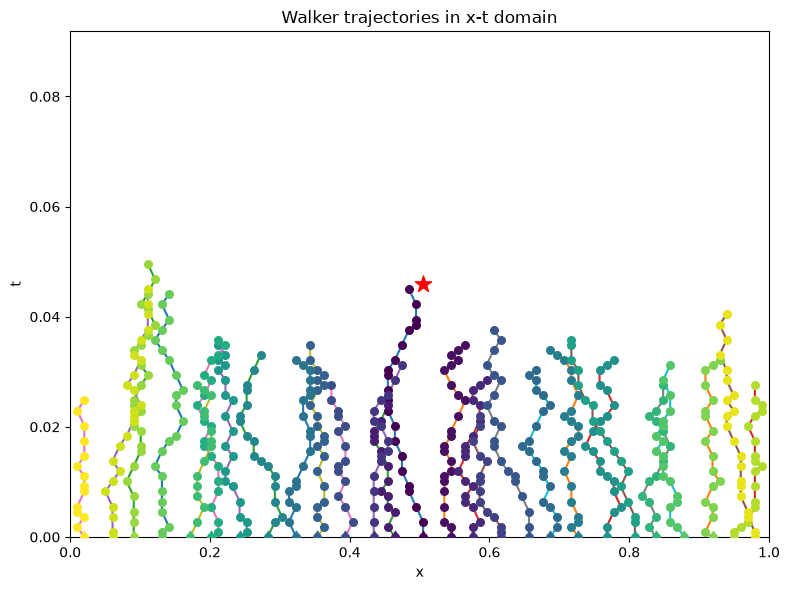

In [7]:
t_star_steps = 50  # ← change this to test different targets
env      = PDEEnvironment(t_star_steps=t_star_steps)
state, _ = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    action = env.action_space.sample()
    state, reward, done, _, info = env.step(action)



    total_accepted += int(info['accepted'])
    if info['rejected']:
        reason = info['rejected']
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts
               if t > 0.0 and 0.0 < x < 1.0]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Total rejected: {sum(total_rejected.values())}")
print("Rejection reasons:")

for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")
# walker distribution check — tells you if one walker is dominating
walker_counts = {}
for i, traj in trajectories.items():
    walker_counts[i] = len(traj) - 1  # subtract starting position
print("\nAccepted moves per walker:")
for i, count in sorted(walker_counts.items()):
    print(f"  Walker {i:d}: {count}")

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = plt.cm.viridis(np.linspace(0, 1, env.N))
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

## Plot Trajactories


In [8]:
def plot_trajectories(model, t_star_steps, N_particles, lam, beta, K_max, c_shape,
                      save=True, timestep=None, img_dir=".", label=None,
                      x_star_steps=None):          # NEW: grid index for x*; None → center
    env = PDEEnvironment(t_star_steps=t_star_steps, N_particles=N_particles,
                         lam=lam, beta=beta, K_max=K_max, c_shape=c_shape,
                         x_star_schedule=None if x_star_steps is None else [x_star_steps])
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True, action_masks=env.action_masks())
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    fig, ax = plt.subplots(figsize=(8, 6))

    vx = [p[0] for p in visited_log]
    vt = [p[1] for p in visited_log]
    ax.scatter(vx, vt, s=4, color='lightgray', zorder=1)

    # ── Rejected positions ───────────────────────────────────────────────────
    rej_colors = {
        'bounds':    'blue',
        'collision': 'orange',
        'cond':      'purple',
        'weights':   'brown',
        'geometry':  'red',
        None:        'gray',
    }
    if env.rejected_history:
        from collections import defaultdict
        by_reason = defaultdict(list)
        for (rx, rt, reason) in env.rejected_history:
            by_reason[reason].append((rx, rt))
        for reason, pts in by_reason.items():
            ax.scatter([p[0] for p in pts], [p[1] for p in pts],
                       s=6, alpha=0.08, linewidths=0, zorder=1,
                       color=rej_colors.get(reason, 'gray'),
                       label=f'rej:{reason} ({len(pts)})')
    # ─────────────────────────────────────────────────────────────────────────

    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]
        ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=1.5, color=colors[i], zorder=2)
        ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
        ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^', zorder=4)

    reached = info.get('reached', False)
    outcome = 'reached' if reached else 'timeout'

    # ── Stencil at z* ────────────────────────────────────────────────────────
    if reached:
        _, success, nb_coords, _ = env._gfdm_solve(env.x_star, env.t_star)
        if success and nb_coords is not None:
            for (nx_, nt_) in nb_coords:
                ax.plot([env.x_star, nx_], [env.t_star, nt_],
                        '--', color='red', linewidth=0.8,
                        alpha=0.7, zorder=5)
            ax.scatter(nb_coords[:, 0], nb_coords[:, 1],
                       s=40, color='red', zorder=6, alpha=0.7)

    ax.scatter(env.x_star, env.t_star, s=150, color='red', marker='*', zorder=7)
    ax.set_xlabel('x')
    ax.set_ylabel('t')

    title = f't_star={t_star_steps}·dt  |  x_star={env.x_star:.2f}  |  {outcome}'
    if timestep is not None:
        title += f'  |  step {timestep:,}'
    if reached and info.get('error') is not None:
        title += f'  |  err={info["error"]:.2e}  |  k={info["k_term"]}'
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, env.t_star * 2)

    if env.rejected_history:
        ax.legend(fontsize=6, loc='upper left', markerscale=2)

    plt.tight_layout()

    if save:
        xtag = "" if x_star_steps is None else f"_x{x_star_steps}"

        if label is not None:
            fname = f'traj_t{t_star_steps}dt{xtag}_{label}_{outcome}.png'
        elif timestep is not None:
            fname = f'traj_t{t_star_steps}dt{xtag}_{timestep//1000:05d}k_{outcome}.png'
        else:
            fname = f'traj_t{t_star_steps}dt{xtag}_{outcome}.png'
        fig.savefig(os.path.join(img_dir, fname), dpi=120)
        plt.close(fig)
    else:
        plt.show()

In [9]:
class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf       = []
        self.kterm_buf = []
        self.err_buf   = []

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached'):
                self.buf.append(1)
                k = info.get('k_term')
                e = info.get('error')
                if k is not None and e is not None:
                    self.kterm_buf.append(k)
                    self.err_buf.append(e)
            elif info.get('timeout'):
                self.buf.append(0)
        if self.buf:
            self.logger.record('rollout/reached_rate',
                               sum(self.buf[-100:]) / len(self.buf[-100:]))
        if self.kterm_buf:
            self.logger.record('rollout/mean_kterm_on_reach',
                               np.mean(self.kterm_buf[-100:]))
            self.logger.record('rollout/mean_error_on_reach',
                               np.mean(self.err_buf[-100:]))
        return True

In [10]:
class PlotCallback(BaseCallback):
    def __init__(self, t_star_steps, N_particles, lam, beta, K_max, c_shape,
                 plot_freq=50_000, img_dir=".", verbose=0,
                 x_star_steps=None):              # NEW
        super().__init__(verbose)
        self.t_star_steps = t_star_steps
        self.N_particles  = N_particles
        self.lam          = lam
        self.beta         = beta
        self.K_max        = K_max
        self.c_shape      = c_shape
        self.plot_freq    = plot_freq
        self.last_plot_at = 0
        self.img_dir      = img_dir
        self.x_star_steps = x_star_steps          # NEW

    def _on_step(self) -> bool:
        if self.num_timesteps - self.last_plot_at >= self.plot_freq:
            self.last_plot_at = self.num_timesteps
            plot_trajectories(self.model, self.t_star_steps, self.N_particles,
                              self.lam, self.beta, self.K_max, self.c_shape,
                              save=True, timestep=self.num_timesteps,
                              img_dir=self.img_dir,
                              x_star_steps=self.x_star_steps)   # NEW
        return True


def make_env(t_star_schedule, N_particles, lam, beta, K_max, c_shape, x_star_schedule):
    def _init():
        env = PDEEnvironment(t_star_schedule=t_star_schedule, N_particles=N_particles,
                             lam=lam, beta=beta, K_max=K_max, c_shape=c_shape,
                             x_star_schedule=x_star_schedule)
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init

In [11]:
N_particles     = 30
t_star_schedule = {5: 60, 10: 120, 15: 240, 20: 480}   # multiple t*, K_max ≈ 12·t*
x_star_schedule = [30, 40, 50, 60, 70]                 # 5 interior x*, all reachable at these t*
seeds           = [5]
lam             = 0.005
beta            = 2000
n_envs          = 15
n_steps         = 2048 // n_envs
total_timesteps = 50_000_000
c_shape         = 0.02

# representative t* used ONLY for periodic plots/videos (policy trains on all keys)
plot_tstar   =5
plot_K_max   = t_star_schedule[plot_tstar]
plot_xstar   = x_star_schedule[0]  # representative x* for plots

# ── Run directory ────────────────────────────────────────────────────────────
day        = date.today().day
stages_str = "-".join(str(s) for s in t_star_schedule.keys())
run_name   = f"t{stages_str}_lam{lam}_beta{beta}_N{N_particles}_c{c_shape}"
run_dir    = os.path.join(f"runs{day}", run_name)

print(f"Run: {run_dir}")
print(f"Training jointly on t*={list(t_star_schedule.keys())}  "
      f"(periodic plots shown at t*={plot_tstar})")

for seed in seeds:

    seed_dir  = os.path.join(run_dir, f"seed{seed}")
    img_dir   = os.path.join(seed_dir, "images")
    ckpt_dir  = os.path.join(seed_dir, "checkpoints")

    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'#'*50}\nSEED {seed}\n{'#'*50}")

    # every subprocess gets the SAME schedule and resamples t* per episode in reset()
    vec_env = SubprocVecEnv([
        make_env(t_star_schedule, N_particles, lam, beta, K_max=None,
                c_shape=c_shape, x_star_schedule=x_star_schedule)
        for _ in range(n_envs)
    ])

    model = MaskablePPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        seed=seed,
        tensorboard_log=os.path.join(seed_dir, "logs"),
        learning_rate=2e-4,
        clip_range=0.1,
        n_steps=n_steps,
        batch_size=60,
        gamma=1.0,
        ent_coef=0.01,
        device="cpu",
    )

    print(f"\n{'='*50}")
    print(f"Joint training over t* schedule: {t_star_schedule}")
    print(f"budget: {total_timesteps//1000}k steps")
    print(f"{'='*50}")

    model.learn(
        total_timesteps=total_timesteps,
        reset_num_timesteps=False,
        tb_log_name=f"seed{seed}",
        log_interval=10,
        callback=[
            ReachedRateCallback(),
            PlotCallback(plot_tstar, N_particles, lam, beta, plot_K_max, c_shape,
                            plot_freq=100_000, img_dir=img_dir, x_star_steps=plot_xstar),
            CheckpointCallback(
                save_freq=100_000,
                save_path=os.path.join(ckpt_dir, "sched"),
                name_prefix="sched"
            ),
        ],
    )

    model.save(os.path.join(ckpt_dir, "sched_final"))

    # final plots/videos at the representative t*
    plot_trajectories(model, plot_tstar, N_particles, lam, beta, plot_K_max, c_shape,
                  save=True, timestep=None, img_dir=img_dir, label="final",
                  x_star_steps=plot_xstar)
    make_training_progress_video(img_dir, plot_tstar, N_particles, lam, beta, plot_K_max, c_shape,
                                 label="final", fps=5)
    make_trajectory_video1(
        model, PDEEnvironment, plot_tstar, N_particles,
        img_dir=img_dir, label="final",
        x_star_steps=plot_xstar,
    )

Run: runs21\t5-10-15-20_lam0.005_beta2000_N30_c0.02
Training jointly on t*=[5, 10, 15, 20]  (periodic plots shown at t*=5)

##################################################
SEED 5
##################################################
Using cpu device

Joint training over t* schedule: {5: 60, 10: 120, 15: 240, 20: 480}
budget: 50000k steps
Logging to runs21\t5-10-15-20_lam0.005_beta2000_N30_c0.02\seed5\logs\seed5_0
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 210         |
|    ep_rew_mean          | -1.35       |
|    mean_error_on_reach  | 6.04e-05    |
|    mean_kterm_on_reach  | 189         |
|    reached_rate         | 0.106       |
| time/                   |             |
|    fps                  | 1292        |
|    iterations           | 10          |
|    time_elapsed         | 15          |
|    total_timesteps      | 20400       |
| train/                  |             |
|    approx_kl            | 0.0061459

TypeError: make_training_progress_video() got an unexpected keyword argument 'label'

Rollout done: timeout, 206 accepted points, 500 total steps.


KeyboardInterrupt: 

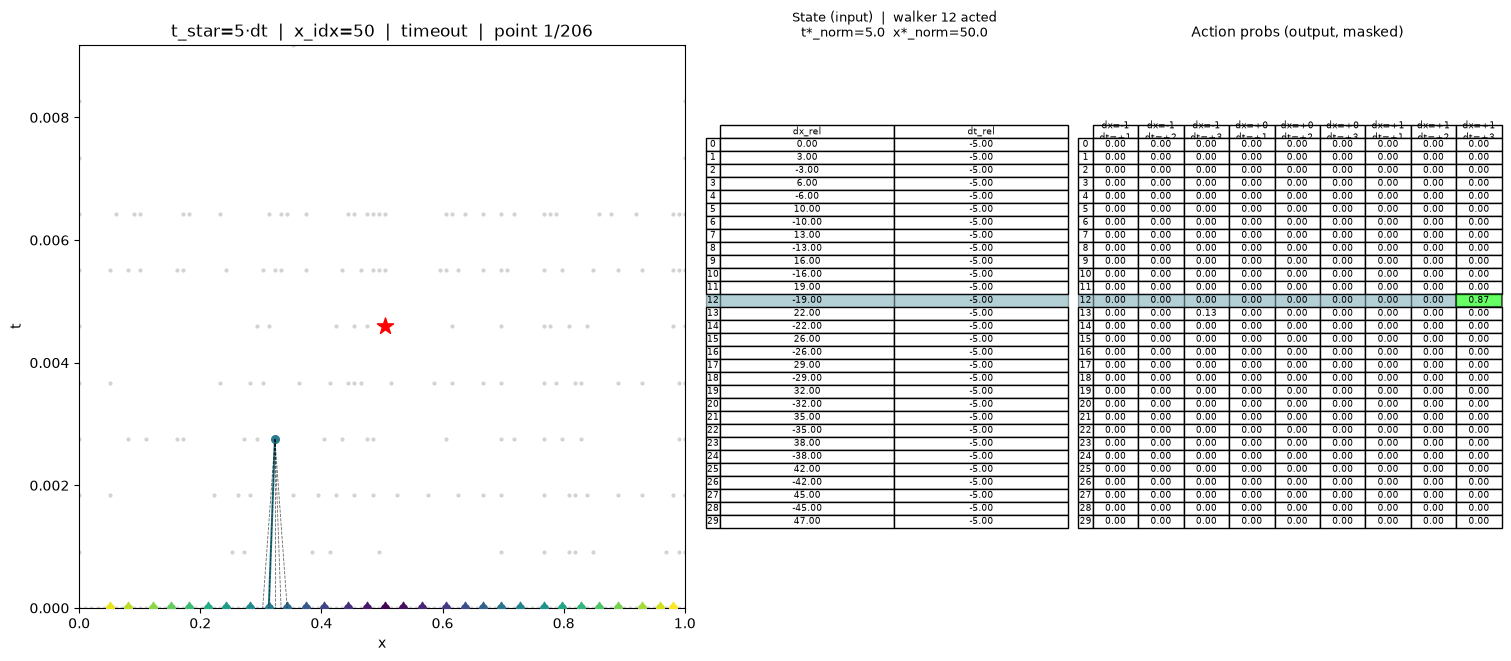

In [13]:
make_trajectory_video1(
        model, PDEEnvironment, plot_tstar, N_particles,
        img_dir=img_dir, label="final",
        x_star_steps=50,
)